<a href="https://colab.research.google.com/github/manideepika-30/NLP/blob/main/Assignment4.3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install wordcloud seaborn


In [3]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud


In [6]:
df = pd.read_csv("arxiv_data.csv", on_bad_lines='warn')
df.head()

,titles,summaries,terms
0,Survey on Semantic Stereo Matching / Semantic ...,Stereo matching is one of the widely used tech...,"['cs.CV', 'cs.LG']"
1,FUTURE-AI: Guiding Principles and Consensus Re...,The recent advancements in artificial intellig...,"['cs.CV', 'cs.AI', 'cs.LG']"
2,Enforcing Mutual Consistency of Hard Regions f...,"In this paper, we proposed a novel mutual cons...","['cs.CV', 'cs.AI']"
3,Parameter Decoupling Strategy for Semi-supervi...,Consistency training has proven to be an advan...,['cs.CV']
4,Background-Foreground Segmentation for Interio...,"To ensure safety in automated driving, the cor...","['cs.CV', 'cs.LG']"


In [8]:
# Select only AI-related abstracts
ai_abstracts = df[df['terms'].str.contains('cs.AI', na=False)]

# Take a small subset
abstracts = ai_abstracts['summaries'].head(5).tolist()

abstracts

["The recent advancements in artificial intelligence (AI) combined with the\nextensive amount of data generated by today's clinical systems, has led to the\ndevelopment of imaging AI solutions across the whole value chain of medical\nimaging, including image reconstruction, medical image segmentation,\nimage-based diagnosis and treatment planning. Notwithstanding the successes and\nfuture potential of AI in medical imaging, many stakeholders are concerned of\nthe potential risks and ethical implications of imaging AI solutions, which are\nperceived as complex, opaque, and difficult to comprehend, utilise, and trust\nin critical clinical applications. Despite these concerns and risks, there are\ncurrently no concrete guidelines and best practices for guiding future AI\ndevelopments in medical imaging towards increased trust, safety and adoption.\nTo bridge this gap, this paper introduces a careful selection of guiding\nprinciples drawn from the accumulated experiences, consensus, and be

In [9]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)       # remove numbers
    text = re.sub(r'[^\w\s]', '', text)   # remove punctuation
    return text

cleaned_abstracts = [clean_text(text) for text in abstracts]
cleaned_abstracts


['the recent advancements in artificial intelligence ai combined with the\nextensive amount of data generated by todays clinical systems has led to the\ndevelopment of imaging ai solutions across the whole value chain of medical\nimaging including image reconstruction medical image segmentation\nimagebased diagnosis and treatment planning notwithstanding the successes and\nfuture potential of ai in medical imaging many stakeholders are concerned of\nthe potential risks and ethical implications of imaging ai solutions which are\nperceived as complex opaque and difficult to comprehend utilise and trust\nin critical clinical applications despite these concerns and risks there are\ncurrently no concrete guidelines and best practices for guiding future ai\ndevelopments in medical imaging towards increased trust safety and adoption\nto bridge this gap this paper introduces a careful selection of guiding\nprinciples drawn from the accumulated experiences consensus and best\npractices from fiv

In [10]:
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(cleaned_abstracts)

feature_names = vectorizer.get_feature_names_out()
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)

tfidf_df.head()


,ablation,according,accumulated,address,adek,adhesive,adoption,advancements,advances,advantages,...,view,vii,vision,vit,volumetric,way,work,workload,works,xray
0,0.000000,0.000000,0.066195,0.000000,0.000000,0.00000,0.066195,0.066195,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.06688,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.06688,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.086725,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.086725,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.086725,0.000000,0.086725
3,0.082917,0.000000,0.000000,0.000000,0.082917,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.066897,0.082917,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.054792,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.054792,0.054792,...,0.000000,0.054792,0.176824,0.000000,0.054792,0.00000,0.054792,0.000000,0.054792,0.000000


In [11]:
top_terms = tfidf_df.sum(axis=0).sort_values(ascending=False).head(20)
top_terms


,0
learning,0.626203
segmentation,0.579847
reinforcement,0.547921
ai,0.463367
model,0.437884
image,0.436384
deep,0.433125
imaging,0.397172
medical,0.369779
generalization,0.346899


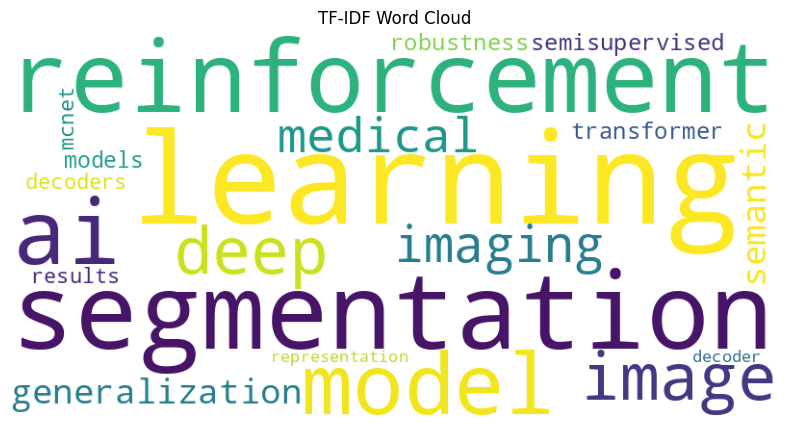

In [12]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate_from_frequencies(top_terms)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("TF-IDF Word Cloud")
plt.show()


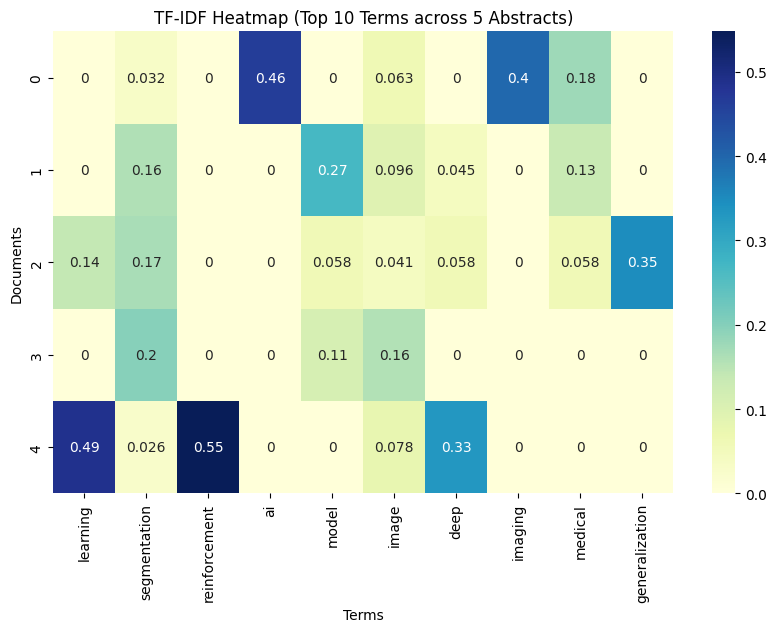

In [13]:
top_10_terms = top_terms.head(10).index
heatmap_data = tfidf_df[top_10_terms]

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu')
plt.title("TF-IDF Heatmap (Top 10 Terms across 5 Abstracts)")
plt.xlabel("Terms")
plt.ylabel("Documents")
plt.show()
